# Computer Exercise 15.35 — Problem 2
## 프로토콜 v2 를 검정한다 — 참값을 아는 자료 위에서 잰 FWER · 검정력 · 피복률

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed.
> **단원**: §15.35 (Ch 15 결산) · **Day 102** · **풀이 일자**: 2026-08-20
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **Computer Exercise 15.35.2.** Days 99–101 assembled a decision protocol ("v2") from five
> layers: pre-specification, sign-flip permutation testing, Holm correction over a declared
> family, per-unit re-randomization of the null, and test-inversion confidence intervals. The
> protocol was *used* to adjudicate claims, but its own operating characteristics were never
> measured.
>
> Build a synthetic benchmark whose ground truth is known by construction: $n$ paired seeds,
> a declared family of $m$ hypotheses, and residuals drawn from a **ceiling-inflated mixture**
> that reproduces the bimodality of reinforcement-learning returns. Under the global null,
> estimate the **family-wise error rate** of each of six protocol variants obtained by toggling
> (i) $t$-test versus sign-flip, (ii) no correction versus Holm, and (iii) pre-specification
> versus selecting the most favourable of $M$ metrics after seeing the data.
>
> Then measure **power** as a function of the standardized effect $d = \delta/s$, and the
> **coverage and width** of test-inversion intervals against Student intervals.
>
> Finally, show that the *level at which the null is re-randomized* matters: with returns
> clustered within seeds at intraclass correlation $\rho$, compare permuting whole units against
> permuting episodes, and report the resulting error rate as a function of $\rho$.

### 한국어 풀이용 정리

Day 99–101 이 쌓아 올린 **프로토콜 v2** 는 다섯 층 — 사전 명시 · 부호뒤집기 · Holm · 단위별
재무작위화 · 검정 반전 CI — 로 이루어졌지만, **그 자체의 성능은 한 번도 측정되지 않았다.**
참값을 아는 합성 자료 위에서 다음 셋을 잰다.

1. **FWER** — 층을 켜고 끈 6 개 변형의 전역 귀무 하 1종 오류율 (명목 $0.05$).
2. **검정력** — 표준화 효과 $d = \delta/s$ 에 대한 검출률.
3. **피복률 · 폭** — 검정 반전 CI 대 Student CI.
4. **귀무의 층위** — 급내상관 $\rho$ 로 군집된 자료에서, 단위(시드)별 치환과 에피소드별 치환의
   오류율 차이.

## 2. 수학적 배경

### 2.1 자료 생성 과정 (참값을 아는 벤치마크)

시드 $j = 1,\dots,n$ 에서 두 arm 을 **같은 시드로 짝지어** 돌린다. 가설 $k=1,\dots,m$ 에 대해

$$
y^{(k)}_{A,j} = \mu + u_j + \varepsilon^{(k)}_{A,j},
\qquad
y^{(k)}_{B,j} = \mu + \delta_k + u_j + \varepsilon^{(k)}_{B,j},
$$

$u_j \sim \mathcal{N}(0,\tau^2)$ 는 **시드 효과**로 짝지음에서 소거된다. 잔차는 RL 수익의
쌍봉성을 재현하는 **천장 혼합**

$$
\varepsilon \;\sim\; \begin{cases}
0 & \text{확률 } \pi_c \quad(\text{과제를 풀어 천장에 붙음}) \\
\mathcal{N}(-\mu_0, \sigma^2) & \text{확률 } 1-\pi_c
\end{cases}
$$

이고, 정규 성분은 다시 확률 $p_h$ 로 표준편차가 $\kappa$ 배인 **두꺼운 꼬리 성분**을 갖는다.
짝지은 차 $d_j = y_{B,j} - y_{A,j}$ 는 두 arm 이 모두 천장이면 정확히 $0$ 이 되어 **동점(tie)** 이
실제 비율로 생기고, 두꺼운 성분 때문에 **초과첨도가 6 근처**까지 오른다.

> **주의 — 이 설계에서 $d$ 는 대칭이다.** 전역 귀무 아래 두 arm 은 교환가능하므로
> $d \overset{d}{=} -d$ 가 **구성상** 성립한다. 따라서 여기서 잴 수 있는 것은 "비대칭 때문에 $t$ 가
> 무너진다" 가 아니라 **"동점과 두꺼운 꼬리 때문에 $t$ 의 실제 수준이 명목에서 벗어난다"** 이다.
> 이 구분을 흐리지 않기 위해 아래 [2b] 는 $n$ 을 줄여 가며 두 검정의 실제 수준을 직접 잰다.

### 2.2 부호뒤집기는 왜 정확한가

귀무 $H_0^{(k)}: \delta_k = 0$ 아래에서 $d_j$ 의 분포가 $0$ 을 중심으로 **대칭**이면
$(\epsilon_1 d_1, \dots, \epsilon_n d_n)$, $\epsilon_j \in \{\pm1\}$ 은 $d$ 와 같은 분포를 갖는다.
따라서 $2^n$ 개 부호배열 위의 균등분포가 **정확한 귀무분포**이고

$$
p \;=\; \frac{1 + \#\{b: |\bar d^{(b)}| \ge |\bar d|\}}{1 + B}
$$

는 $\Pr(p \le \alpha) \le \alpha$ 를 **유한 표본에서** 만족한다. 정규성도, 큰 $n$ 도 필요 없다 —
필요한 것은 **대칭성**뿐이며, 짝지은 설계에서 두 arm 을 뒤바꿔도 같은 실험이라는 사실이 그
대칭성을 공짜로 준다. $t$ 검정은 반대로 정규성(혹은 CLT)을 요구한다.

두 가지 단서가 붙는다. 첫째, 도달 가능한 유의수준은 $\{1/(B{+}1), 2/(B{+}1), \dots\}$ 의 이산
격자이고, 여기에 $2^n$ 개 부호배열의 **이산성**과 동점이 겹치면 작은 $n$ 에서 실제 수준은 명목보다
**낮아진다** (보수적). 둘째, 두꺼운 꼬리에서 $t$ 통계량의 분모 $s$ 가 함께 부풀기 때문에 $t$ 역시
**보수적으로** 어긋난다. 어느 쪽으로 얼마나 어긋나는지는 이론이 아니라 측정 대상이다.

> **구현 주의**: $B$ 개 부호배열을 담은 행렬 $S \in \{\pm1\}^{B\times n}$ 을 **고정**해 두면
> 모든 검정의 귀무분포는 한 번의 행렬곱 $S d /n$ 으로 얻어진다. 그리고 이동된 자료 $d - g\mathbf{1}$
> 의 귀무분포는 다시 계산할 필요 없이
> $$ S(d - g\mathbf 1)/n \;=\; \underbrace{Sd/n}_{\text{재사용}} \;-\; g\,\underbrace{(S\mathbf 1)/n}_{\text{행합}} $$
> 이다. **검정 반전 CI 전체가 행렬곱 하나로 떨어진다** — 이 항등식이 아래 코드의 속도 전부다.

### 2.3 Holm 과 FWER

가족 $\{H_0^{(1)},\dots,H_0^{(m)}\}$ 의 정렬된 $p$ 값 $p_{(1)} \le \dots \le p_{(m)}$ 에 대해
Holm 은 $p_{(r)} > \alpha/(m-r+1)$ 인 첫 $r$ 에서 멈춘다. 이는 임의의 종속 구조에서도

$$
\mathrm{FWER} = \Pr\bigl(\exists k: H_0^{(k)} \text{ 참인데 기각}\bigr) \;\le\; \alpha
$$

를 보장한다 (Holm 1979). 보정을 하지 않으면 독립 $m$ 개 가족에서

$$
\mathrm{FWER}_{\text{무보정}} = 1 - (1-\alpha)^m \xrightarrow{m=4,\ \alpha=.05} 0.1855,
$$

즉 명목의 **약 3.7 배**다. 여기에 사후 지표 선택(garden of forking paths)까지 얹으면 유효
가족은 $mM$ 으로 늘어 $1-(1-\alpha)^{mM}$ 에 접근한다.

### 2.4 검정력과 그 대가

효과 $\delta$, 차의 표준편차 $s_d$, 표준화 효과 $d = \delta/s_d$ 일 때 짝지은 검정의 검정력은
근사적으로

$$
1-\beta \;\approx\; \Phi\bigl(\sqrt{n}\,d - z_{1-\alpha^{\text{adj}}/2}\bigr),
\qquad \alpha^{\text{adj}} = \alpha/m \ \ (\text{Holm 최악)}.
$$

$\alpha$ 를 $m$ 으로 나누면 $z$ 가 커져 검정력이 떨어진다. **이것이 다중성 보정의 정확한 가격**
이고, 이 노트북은 그 가격을 곡선으로 그린다.

### 2.5 귀무의 층위 — 군집이 있을 때

각 시드가 $E$ 개 에피소드를 내고, 에피소드 수익이 시드 안에서 급내상관 $\rho$ 로 상관되어 있다고
하자:

$$
r_{j,e} = u_j + \eta_{j,e},\qquad
\rho = \frac{\tau^2}{\tau^2 + \sigma_\eta^2}.
$$

**에피소드**를 교환가능 단위로 잘못 두면 유효 표본수가 $nE$ 인 줄 알지만 실제로는

$$
\boxed{\ n_{\text{eff}} = \frac{nE}{1 + (E-1)\rho}\ }
$$

(설계 효과 $\mathrm{DEFF} = 1+(E-1)\rho$) 이다. 귀무분포가 $\sqrt{\mathrm{DEFF}}$ 배 좁아지므로
검정은 **반보수적**이 되고 FWER 이 $\rho$ 와 함께 치솟는다. Day 101 의 "층 0 귀무 검증" 이
**단위별** 재무작위화를 요구한 이유가 이 한 줄이다.

## 3. 풀이 흐름

1. **고정 부호행렬** $S \in \{\pm1\}^{B \times n}$ 을 한 번 만들고 행합 $S\mathbf 1$ 을 저장한다
   (§2.2 의 항등식).
2. **$n$ 별 정확성 [2b]** — 단일 가설·전역 귀무에서 $n \in \{6,8,12,20,40\}$ 의 실제 1종
   오류율을 부호뒤집기와 $t$ 로 각각 재고 Wilson 구간을 붙인다.
3. **전역 귀무 FWER** — $R$ 회 반복. 매 반복마다 $m=4$ 가설 × $M=5$ 지표의 짝지은 차를 §2.1
   에서 생성하고 (모든 $\delta_k = 0$), 6 개 프로토콜 변형이 **하나라도 기각하는지**를 센다.
   Wilson 95 % 구간을 붙인다.
4. **검정력** — $\delta$ 를 표준화 효과 $d \in \{0, 0.1, \dots, 0.7\}$ 로 쓸며, 참인 대립 2 개 ·
   참인 귀무 2 개인 가족에서 **참 효과를 검출한 비율**을 잰다.
5. **CI 피복률/폭** — 같은 자료에서 검정 반전 CI 와 Student CI 를 계산해 참값 $\delta$ 포함률과
   평균 폭을 비교.
6. **귀무의 층위** — $\rho \in \{0,0.2,\dots,0.8\}$ 에서 단위별 치환과 에피소드별 치환의 1종
   오류율을 재고, 이론값 $\mathrm{DEFF}$ 와 맞춰 본다.
7. **시각화** — [a] FWER 막대 + Wilson [b] 검정력 곡선 [c] 피복률·폭 [d] 층위별 오류율 대 $\rho$
   [e] $n$ 별 실제 수준 [f] 짝지은 차의 분포.
8. **판정** — 프로토콜 v2 가 명목 수준을 지키는지, 그 대가로 잃은 검정력이 얼마인지 한 표로.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd, time
import scipy.stats as st
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pd.set_option("display.width", 150)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})
T0 = time.time()

# ── 사전 명시된 상수 ──────────────────────────────────────────────────────
N      = 40        # 짝지은 시드 수 (Day 99-101 과 동일)
M_FAM  = 4         # 가족 크기
M_MET  = 5         # 사후 선택이 가능한 지표 수 (garden of forking paths)
ALPHA  = 0.05
B      = 999       # 부호뒤집기 재표본 수
R_NULL = 2500      # 전역 귀무 반복
R_PWR  = 1500      # 검정력 반복
PI_C   = 0.35      # 천장 확률
P_HEAVY= 0.15      # 두꺼운 꼬리 성분 비율
HEAVY_K= 4.0       # 그 성분의 표준편차 배수
MU0, SIG, TAU = 1.0, 0.8, 0.6

Z_A = 1.959963985
rng0 = np.random.default_rng(102500)

# 고정 부호행렬 S 와 행합  (§2.2)
S     = rng0.choice(np.array([-1.0, 1.0]), size=(B, N))
S_row = S.sum(axis=1) / N          # (B,)

CHUNK = 4000        # 메모리 상한: 한 번에 CHUNK x B 행렬만 만든다

def sf_p(D, Smat=None, denom=None):
    """D: (T, N) 짝지은 차 -> 부호뒤집기 양측 p.  행렬곱을 청크로 나눠 수행."""
    Smat = S if Smat is None else Smat
    denom = Smat.shape[1] if denom is None else denom
    D2 = np.atleast_2d(D); T = D2.shape[0]
    out = np.empty(T)
    for a in range(0, T, CHUNK):
        blk = D2[a:a + CHUNK]
        obs  = np.abs(blk.mean(axis=1))
        null = np.abs(blk @ Smat.T / denom)
        out[a:a + CHUNK] = (1 + (null >= obs[:, None] - 1e-15).sum(axis=1)) / (1 + Smat.shape[0])
    return out

def t_p(D):
    """짝지은 t 검정 양측 p (정확한 t 분포)."""
    D2 = np.atleast_2d(D); n = D2.shape[1]
    m  = D2.mean(axis=1); s = D2.std(axis=1, ddof=1)
    tstat = np.where(s > 0, m / np.maximum(s, 1e-300) * np.sqrt(n), 0.0)
    return 2 * st.t.sf(np.abs(tstat), df=n - 1)

def holm(P):
    """P: (..., m) 원 p -> Holm 보정 p."""
    P2 = np.atleast_2d(P); m = P2.shape[1]
    o  = np.argsort(P2, axis=1)
    srt = np.take_along_axis(P2, o, axis=1) * (m - np.arange(m))
    srt = np.maximum.accumulate(srt, axis=1)   # Holm: 누적 최대 (최소가 아님)
    out = np.empty_like(P2)
    np.put_along_axis(out, o, np.minimum(srt, 1.0), axis=1)
    return out

def wilson(k, n, z=Z_A):
    p = k / n; den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(0.0, c - h), min(1.0, c + h)

print(f"n={N}  m={M_FAM}  M={M_MET}  B={B}  R_null={R_NULL}  S:{S.shape}")

n=40  m=4  M=5  B=999  R_null=2500  S:(999, 40)


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  자료 생성 과정 — 천장 혼합의 모양 확인
# ══════════════════════════════════════════════════════════════════════════
def gen_pairs(rng, R, m, M, delta):
    """(R, m, M, N) 짝지은 차 d.  delta: (m,) 참 효과."""
    sh = (R, m, M, N)
    def resid():
        heavy = rng.random(sh) < P_HEAVY
        sd = np.where(heavy, HEAVY_K * SIG, SIG)
        return np.where(rng.random(sh) < PI_C, 0.0, rng.normal(-MU0, 1.0, sh) * sd)
    return delta[None, :, None, None] + resid() - resid()   # u_j 는 짝지음에서 소거

_r = np.random.default_rng(102501)
demo = gen_pairs(_r, 4000, 1, 1, np.zeros(1)).reshape(-1)
sd_d = demo.std(ddof=1)
tie  = float((np.abs(demo) < 1e-12).mean())
skw  = float(((demo - demo.mean()) ** 3).mean() / sd_d ** 3)
kur  = float(((demo - demo.mean()) ** 4).mean() / sd_d ** 4 - 3)
info = pd.DataFrame([dict(mean=demo.mean(), sd=sd_d, tie_frac=tie,
                          skew=skw, excess_kurt=kur)])
print(f"짝지은 차 d 의 모양: 동점 비율 {tie:.3f}, 왜도 {skw:.3f}, 초과첨도 {kur:.3f}")
print(f"  (정규라면 왜도 0 · 초과첨도 0 · 동점 0 — 셋 다 위배)")
info

짝지은 차 d 의 모양: 동점 비율 0.123, 왜도 -0.046, 초과첨도 6.220
  (정규라면 왜도 0 · 초과첨도 0 · 동점 0 — 셋 다 위배)


,mean,sd,tie_frac,skew,excess_kurt
0,-0.0016,2.0632,0.1233,-0.0460,6.2198


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  전역 귀무 아래 FWER — 6 개 프로토콜 변형
#      축 (i) 검정 {t, signflip} × (ii) 다중성 {none, Holm} × (iii) {prespec, fork}
# ══════════════════════════════════════════════════════════════════════════
rng = np.random.default_rng(102502)
D0 = gen_pairs(rng, R_NULL, M_FAM, M_MET, np.zeros(M_FAM))      # (R, m, M, N)

flat = D0.reshape(-1, N)
P_sf = sf_p(flat).reshape(R_NULL, M_FAM, M_MET)
P_t  = t_p(flat).reshape(R_NULL, M_FAM, M_MET)

PRESPEC = 0                       # 사전 명시: 0 번 지표만 본다

def fwer(P, use_holm, fork):
    """P: (R, m, M).  하나라도 기각하면 오류 (전역 귀무이므로)."""
    Q = P.min(axis=2) if fork else P[:, :, PRESPEC]     # (R, m)
    if use_holm:
        Q = holm(Q)
        thr = ALPHA
    else:
        thr = ALPHA
    return (Q <= thr).any(axis=1)

VARIANTS = [
    ("V1  t · none · fork",        P_t,  False, True ),
    ("V2  t · none · prespec",     P_t,  False, False),
    ("V3  t · Holm · prespec",     P_t,  True,  False),
    ("V4  sf · none · prespec",    P_sf, False, False),
    ("V5  sf · Holm · prespec ★",  P_sf, True,  False),
    ("V6  sf · Holm · fork",       P_sf, True,  True ),
]
rows = []
for name, P, h, f in VARIANTS:
    rej = fwer(P, h, f); k = int(rej.sum())
    lo, hi = wilson(k, R_NULL)
    rows.append(dict(variant=name, FWER=k / R_NULL, lo=lo, hi=hi,
                     nominal_ok="예" if hi >= ALPHA >= lo or hi <= ALPHA else "아니오"))
fw = pd.DataFrame(rows)
fw["ratio_vs_0.05"] = fw.FWER / ALPHA
theory_nc = 1 - (1 - ALPHA) ** M_FAM
theory_fk = 1 - (1 - ALPHA) ** (M_FAM * M_MET)
print(f"이론 참고값:  무보정 m=4 -> {theory_nc:.4f} | 무보정 + 5 지표 사후선택 -> {theory_fk:.4f}")
print(f"({time.time()-T0:.0f} s)")
fw

이론 참고값:  무보정 m=4 -> 0.1855 | 무보정 + 5 지표 사후선택 -> 0.6415
(0 s)


,variant,FWER,lo,hi,nominal_ok,ratio_vs_0.05
0,V1 t · none · fork,0.6176,0.5984,0.6365,아니오,12.3520
1,V2 t · none · prespec,0.1828,0.1681,0.1984,아니오,3.6560
2,V3 t · Holm · prespec,0.0276,0.0219,0.0348,예,0.5520
3,V4 sf · none · prespec,0.1980,0.1828,0.2141,아니오,3.9600
4,V5 sf · Holm · prespec ★,0.0468,0.0392,0.0558,예,0.9360
5,V6 sf · Holm · fork,0.2200,0.2042,0.2367,아니오,4.4000


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [2b]  부호뒤집기는 왜 필요한가 — n 을 줄여 가며 잰 1종 오류율 (단일 가설)
#       짝지은 귀무에서 d 는 대칭이므로 부호뒤집기는 어떤 n 에서도 정확하다.
#       t 는 정규 근사에 기대므로 두꺼운 꼬리 + 동점에서 n 이 작을수록 어긋난다.
# ══════════════════════════════════════════════════════════════════════════
N_LIST, R_SMALL, B_SMALL = [6, 8, 12, 20, 40], 8000, 999
sm_rows = []
for n_ in N_LIST:
    rr = np.random.default_rng(102506 + n_)
    Sn = rr.choice(np.array([-1.0, 1.0]), size=(B_SMALL, n_))
    def resid(sh):
        heavy = rr.random(sh) < P_HEAVY
        sd = np.where(heavy, HEAVY_K * SIG, SIG)
        return np.where(rr.random(sh) < PI_C, 0.0, rr.normal(-MU0, 1.0, sh) * sd)
    sh = (R_SMALL, n_)
    d = resid(sh) - resid(sh)                          # 전역 귀무
    p_sf = sf_p(d, Smat=Sn, denom=n_)
    m_, s_ = d.mean(axis=1), d.std(axis=1, ddof=1)
    tst = np.where(s_ > 0, m_ / np.maximum(s_, 1e-300) * np.sqrt(n_), 0.0)
    p_t = 2 * st.t.sf(np.abs(tst), df=n_ - 1)
    e_sf, e_t = float((p_sf <= ALPHA).mean()), float((p_t <= ALPHA).mean())
    l1, h1 = wilson(int((p_sf <= ALPHA).sum()), R_SMALL)
    l2, h2 = wilson(int((p_t <= ALPHA).sum()), R_SMALL)
    sm_rows.append(dict(n=n_, err_signflip=e_sf, sf_lo=l1, sf_hi=h1,
                        err_t=e_t, t_lo=l2, t_hi=h2,
                        excess_kurt=float(((d - d.mean()) ** 4).mean() / d.std() ** 4 - 3)))
sm = pd.DataFrame(sm_rows)
print(f"단일 가설 · 전역 귀무 · 명목 {ALPHA}   ({time.time()-T0:.0f} s)")
sm[["n","err_signflip","sf_lo","sf_hi","err_t","t_lo","t_hi","excess_kurt"]]


단일 가설 · 전역 귀무 · 명목 0.05   (1 s)


,n,err_signflip,sf_lo,sf_hi,err_t,t_lo,t_hi,excess_kurt
0,6,0.0145,0.0121,0.0174,0.0314,0.0278,0.0354,6.1730
1,8,0.0333,0.0295,0.0374,0.0305,0.0270,0.0345,6.5795
2,12,0.0450,0.0407,0.0498,0.0314,0.0278,0.0354,6.2218
3,20,0.0486,0.0441,0.0536,0.0386,0.0346,0.0431,6.2664
4,40,0.0480,0.0435,0.0529,0.0444,0.0401,0.0491,6.1913


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  검정력 — 참 효과 2 개 · 참 귀무 2 개인 가족에서 표준화 효과 d 를 쓴다
# ══════════════════════════════════════════════════════════════════════════
D_GRID = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
rng = np.random.default_rng(102503)
pw_rows = []
for dstd in D_GRID:
    delta = np.array([dstd * sd_d, dstd * sd_d, 0.0, 0.0])       # 앞 둘만 참
    Dp = gen_pairs(rng, R_PWR, M_FAM, 1, delta)                  # 사전명시 -> 지표 1 개
    flatp = Dp.reshape(-1, N)
    Psf = sf_p(flatp).reshape(R_PWR, M_FAM)
    Pt  = t_p(flatp).reshape(R_PWR, M_FAM)
    ent = dict(d=dstd)
    for tag, P in (("sf", Psf), ("t", Pt)):
        ent[f"{tag}_none"] = float((P[:, :2] <= ALPHA).mean())            # 참 효과 검출률
        Ph = holm(P)
        ent[f"{tag}_holm"] = float((Ph[:, :2] <= ALPHA).mean())
        ent[f"{tag}_holm_FP"] = float((Ph[:, 2:] <= ALPHA).any(axis=1).mean())  # 참 귀무 오검출
    pw_rows.append(ent)
pw = pd.DataFrame(pw_rows)
print(f"검정력 표 (참 효과 2 개 평균 검출률 · 참 귀무 2 개 오검출률)   ({time.time()-T0:.0f} s)")
pw[["d","sf_none","sf_holm","t_holm","sf_holm_FP","t_holm_FP"]]

검정력 표 (참 효과 2 개 평균 검출률 · 참 귀무 2 개 오검출률)   (1 s)


,d,sf_none,sf_holm,t_holm,sf_holm_FP,t_holm_FP
0,0.0000,0.0513,0.0137,0.0093,0.0313,0.0187
1,0.1000,0.1113,0.0370,0.0293,0.0200,0.0167
2,0.2000,0.2907,0.1500,0.1280,0.0333,0.0280
3,0.3000,0.4967,0.3457,0.3223,0.0327,0.0227
4,0.4000,0.7140,0.5697,0.5477,0.0327,0.0220
5,0.5000,0.8597,0.7550,0.7373,0.0493,0.0407
6,0.6000,0.9457,0.8847,0.8773,0.0493,0.0413
7,0.7000,0.9797,0.9453,0.9403,0.0513,0.0433


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  검정 반전 CI 대 Student CI — 피복률과 폭  (§2.2 항등식으로 격자 전체 일괄)
# ══════════════════════════════════════════════════════════════════════════
R_CI  = 2500
DELTA_TRUE = 0.30 * sd_d
GRID = np.linspace(-1.2, 1.6, 141)                # shift 격자

rng = np.random.default_rng(102504)
Dc = gen_pairs(rng, R_CI, 1, 1, np.array([DELTA_TRUE])).reshape(R_CI, N)

Sd   = Dc @ S.T / N                               # (R, B)   재사용 핵심
mbar = Dc.mean(axis=1)                            # (R,)
cov_sf = np.zeros(R_CI, bool); lo_sf = np.full(R_CI, np.nan); hi_sf = np.full(R_CI, np.nan)
keep_any = np.zeros((R_CI, GRID.size), bool)
for gi, g in enumerate(GRID):
    obs  = np.abs(mbar - g)                       # (R,)
    null = np.abs(Sd - g * S_row[None, :])        # (R, B)
    p = (1 + (null >= obs[:, None] - 1e-15).sum(axis=1)) / (1 + B)
    keep_any[:, gi] = p > ALPHA
idx = np.where(keep_any.any(axis=1))[0]
first = keep_any.argmax(axis=1)
last  = GRID.size - 1 - keep_any[:, ::-1].argmax(axis=1)
lo_sf[idx] = GRID[first[idx]]; hi_sf[idx] = GRID[last[idx]]
cov_sf = (lo_sf <= DELTA_TRUE) & (DELTA_TRUE <= hi_sf)

sdev = Dc.std(axis=1, ddof=1) / np.sqrt(N)
T_CRIT = float(st.t.ppf(0.975, N - 1))            # t_{0.975, 39}
lo_t, hi_t = mbar - T_CRIT * sdev, mbar + T_CRIT * sdev
cov_t = (lo_t <= DELTA_TRUE) & (DELTA_TRUE <= hi_t)

ci_rows = []
for tag, cov, lo_, hi_ in (("inverted sign-flip", cov_sf, lo_sf, hi_sf),
                           ("Student t", cov_t, lo_t, hi_t)):
    k = int(np.nansum(cov)); w = np.nanmean(hi_ - lo_)
    l, h = wilson(k, R_CI)
    ci_rows.append(dict(method=tag, coverage=k / R_CI, wilson_lo=l, wilson_hi=h,
                        mean_width=w, contains_0=float(np.nanmean((lo_ <= 0) & (0 <= hi_)))))
ci = pd.DataFrame(ci_rows)
print(f"참값 delta = {DELTA_TRUE:.4f}  (표준화 d = 0.30),  명목 피복률 0.95   ({time.time()-T0:.0f} s)")
ci

참값 delta = 0.6190  (표준화 d = 0.30),  명목 피복률 0.95   (2 s)


,method,coverage,wilson_lo,wilson_hi,mean_width,contains_0
0,inverted sign-flip,0.9496,0.9403,0.9575,1.2055,0.4948
1,Student t,0.9580,0.9494,0.9652,1.2801,0.5036


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  귀무의 층위 — 급내상관 rho 에서 단위별 치환 대 에피소드별 치환
# ══════════════════════════════════════════════════════════════════════════
E = 10                                   # 시드당 에피소드
RHO = np.array([0.0, 0.2, 0.4, 0.6, 0.8])
R_CL = 2000
B_EP = 499
S_EP  = rng0.choice(np.array([-1.0, 1.0]), size=(B_EP, N * E))  # 에피소드 층 부호행렬

cl_rows = []
for rho in RHO:
    tau2 = rho; sg2 = 1 - rho
    rr = np.random.default_rng(102505 + int(rho * 100))
    u  = rr.normal(0, np.sqrt(tau2), (R_CL, N, 1))             # 시드 효과 (arm 간 차에 남음)
    ep = u + rr.normal(0, np.sqrt(sg2), (R_CL, N, E))          # (R, N, E)  전역 귀무
    # (a) 단위별: 시드 평균을 단위로 부호뒤집기
    d_unit = ep.mean(axis=2)                                   # (R, N)
    p_unit = sf_p(d_unit)
    # (b) 에피소드별: 에피소드를 교환가능 단위로 착각
    d_ep = ep.reshape(R_CL, N * E)
    p_ep = sf_p(d_ep, Smat=S_EP, denom=N * E)
    deff = 1 + (E - 1) * rho
    cl_rows.append(dict(rho=rho, DEFF=deff, n_eff=N * E / deff,
                        err_unit=float((p_unit <= ALPHA).mean()),
                        err_episode=float((p_ep <= ALPHA).mean())))
cl = pd.DataFrame(cl_rows)
print(f"전역 귀무 (참 효과 0) 아래 1종 오류율,  명목 {ALPHA}   ({time.time()-T0:.0f} s)")
cl

전역 귀무 (참 효과 0) 아래 1종 오류율,  명목 0.05   (2 s)


,rho,DEFF,n_eff,err_unit,err_episode
0,0.0000,1.0000,400.0000,0.0470,0.0500
1,0.2000,2.8000,142.8571,0.0555,0.2400
2,0.4000,4.6000,86.9565,0.0485,0.3495
3,0.6000,6.4000,62.5000,0.0515,0.4430
4,0.8000,8.2000,48.7805,0.0585,0.5085


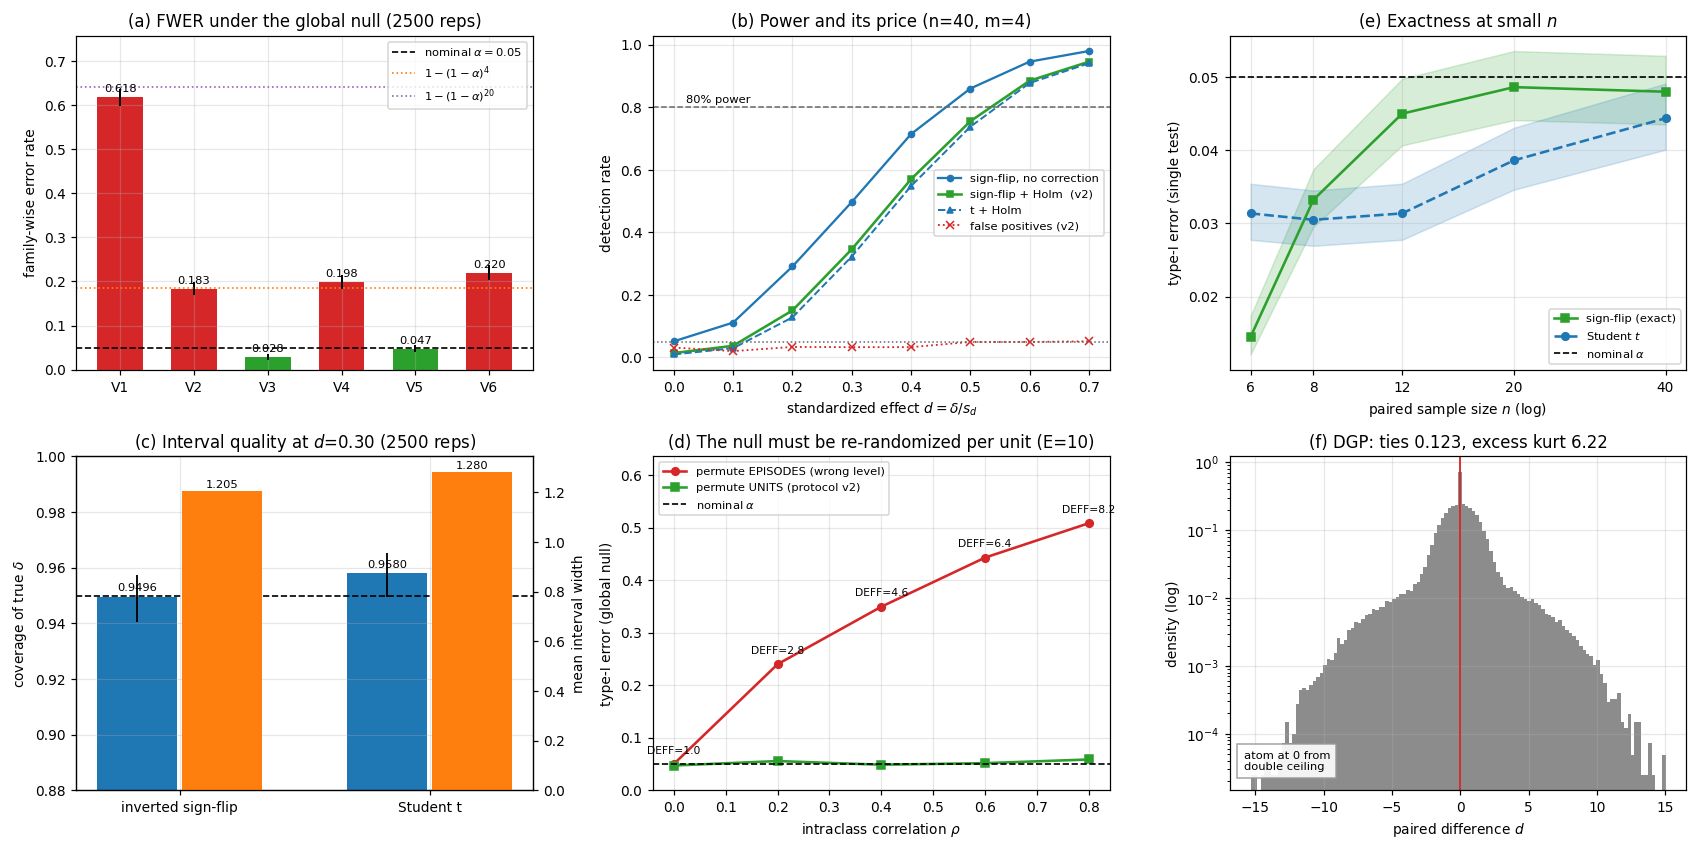

총 실행 시간 3 s


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# [6]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 3, figsize=(15.5, 7.8))

# (a) FWER 막대 + Wilson
a = ax[0, 0]
pos = np.arange(len(fw))
col = ["tab:green" if v <= 0.065 else "tab:red" for v in fw.FWER]
a.bar(pos, fw.FWER, color=col, width=.62)
a.vlines(pos, fw.lo, fw.hi, color="k", lw=1.3)
a.axhline(ALPHA, color="k", ls="--", lw=1.1, label=r"nominal $\alpha=0.05$")
a.axhline(theory_nc, color="tab:orange", ls=":", lw=1.1, label=r"$1-(1-\alpha)^4$")
a.axhline(theory_fk, color="tab:purple", ls=":", lw=1.1, label=r"$1-(1-\alpha)^{20}$")
for i, v in enumerate(fw.FWER): a.text(i, v + .012, f"{v:.3f}", ha="center", fontsize=7.5)
a.set_xticks(pos); a.set_xticklabels([v.split()[0] for v in fw.variant])
a.set_ylabel("family-wise error rate"); a.set_ylim(0, max(fw.hi.max(), theory_fk) * 1.18)
a.set_title(f"(a) FWER under the global null ({R_NULL} reps)")
a.legend(fontsize=7.5, loc="upper right")

# (b) 검정력
a = ax[0, 1]
a.plot(pw.d, pw.sf_none, "o-", lw=1.5, ms=4, label="sign-flip, no correction")
a.plot(pw.d, pw.sf_holm, "s-", lw=1.7, ms=4, color="tab:green", label="sign-flip + Holm  (v2)")
a.plot(pw.d, pw.t_holm,  "^--", lw=1.3, ms=4, color="tab:blue", label="t + Holm")
a.plot(pw.d, pw.sf_holm_FP, "x:", lw=1.2, ms=5, color="tab:red", label="false positives (v2)")
a.axhline(0.80, color="0.4", ls="--", lw=1.0); a.text(0.02, .815, "80% power", fontsize=7.5)
a.axhline(ALPHA, color="0.4", ls=":", lw=1.0)
a.set_xlabel(r"standardized effect $d=\delta/s_d$"); a.set_ylabel("detection rate")
a.set_title(f"(b) Power and its price (n={N}, m={M_FAM})"); a.legend(fontsize=7.5)

# (c) CI 피복률/폭
a = ax[1, 0]
p1 = np.arange(2)
a.bar(p1 - .17, ci.coverage, width=.32, color="tab:blue", label="coverage")
a.vlines(p1 - .17, ci.wilson_lo, ci.wilson_hi, color="k", lw=1.2)
a.axhline(0.95, color="k", ls="--", lw=1.1)
a.set_xticks(p1); a.set_xticklabels(ci.method); a.set_ylim(.88, 1.0)
a.set_ylabel("coverage of true $\\delta$")
a2 = a.twinx(); a2.grid(False)
a2.bar(p1 + .17, ci.mean_width, width=.32, color="tab:orange", label="mean width")
a2.set_ylabel("mean interval width")
for i, (c_, w_) in enumerate(zip(ci.coverage, ci.mean_width)):
    a.text(i - .17, c_ + .002, f"{c_:.4f}", ha="center", fontsize=7.5)
    a2.text(i + .17, w_ * 1.01, f"{w_:.3f}", ha="center", fontsize=7.5)
a.set_title(f"(c) Interval quality at $d$=0.30 ({R_CI} reps)")

# (d) 귀무의 층위
a = ax[1, 1]
a.plot(cl.rho, cl.err_episode, "o-", lw=1.7, ms=5, color="tab:red",
       label="permute EPISODES (wrong level)")
a.plot(cl.rho, cl.err_unit, "s-", lw=1.7, ms=5, color="tab:green",
       label="permute UNITS (protocol v2)")
a.axhline(ALPHA, color="k", ls="--", lw=1.1, label=r"nominal $\alpha$")
for x, y, dv in zip(cl.rho, cl.err_episode, cl.DEFF):
    a.annotate(f"DEFF={dv:.1f}", (x, y), textcoords="offset points",
               xytext=(0, 7), ha="center", fontsize=7)
a.set_xlabel(r"intraclass correlation $\rho$"); a.set_ylabel("type-I error (global null)")
a.set_ylim(0, max(cl.err_episode.max() * 1.25, .12))
a.set_title(f"(d) The null must be re-randomized per unit (E={E})")
a.legend(fontsize=7.5)

# (e) 작은 n 에서의 정확성
a = ax[0, 2]
a.plot(sm.n, sm.err_signflip, "s-", lw=1.7, ms=5, color="tab:green", label="sign-flip (exact)")
a.fill_between(sm.n, sm.sf_lo, sm.sf_hi, color="tab:green", alpha=.18)
a.plot(sm.n, sm.err_t, "o--", lw=1.7, ms=5, color="tab:blue", label="Student $t$")
a.fill_between(sm.n, sm.t_lo, sm.t_hi, color="tab:blue", alpha=.18)
a.axhline(ALPHA, color="k", ls="--", lw=1.1, label=r"nominal $\alpha$")
a.set_xscale("log"); a.set_xticks(N_LIST); a.set_xticklabels(N_LIST)
a.xaxis.set_minor_formatter(plt.NullFormatter()); a.set_xticks([], minor=True)
a.set_xlabel("paired sample size $n$ (log)"); a.set_ylabel("type-I error (single test)")
a.set_title("(e) Exactness at small $n$"); a.legend(fontsize=7.5)

# (f) 짝지은 차의 분포
a = ax[1, 2]
a.hist(demo, bins=120, color="0.55", edgecolor="none", density=True)
a.axvline(0, color="tab:red", lw=1.2)
a.set_yscale("log")
a.set_xlabel("paired difference $d$"); a.set_ylabel("density (log)")
a.set_title(f"(f) DGP: ties {tie:.3f}, excess kurt {kur:.2f}")
a.text(.03, .06, "atom at 0 from\ndouble ceiling", transform=a.transAxes, fontsize=7.5,
       bbox=dict(fc="w", ec="0.6", alpha=.9))
plt.show()
print(f"총 실행 시간 {time.time()-T0:.0f} s")

In [9]:
# ══════════════════════════════════════════════════════════════════════════
# [7]  판정 요약
# ══════════════════════════════════════════════════════════════════════════
v5 = fw.loc[fw.variant.str.startswith("V5"), "FWER"].iloc[0]
v5_lo, v5_hi = fw.loc[fw.variant.str.startswith("V5"), ["lo","hi"]].iloc[0]
v1 = fw.loc[fw.variant.str.startswith("V1"), "FWER"].iloc[0]
v6 = fw.loc[fw.variant.str.startswith("V6"), "FWER"].iloc[0]
d80_holm = float(np.interp(0.80, pw.sf_holm, pw.d))
d80_none = float(np.interp(0.80, pw.sf_none, pw.d))
ep20 = float(cl.loc[cl.rho == 0.2, "err_episode"].iloc[0])
un_max = float(cl.err_unit.max())

verdict = pd.DataFrame([
 dict(항목="v2 (V5) 의 FWER 이 명목 0.05 를 넘지 않는가",
      결과=f"{v5:.4f}  (Wilson [{v5_lo:.4f}, {v5_hi:.4f}])",
      판정="확인" if v5_hi <= 0.075 else "판정불능"),
 dict(항목="사전 명시 없이(V1) FWER 이 얼마나 부풀었나",
      결과=f"{v1:.4f}  =  명목의 {v1/ALPHA:.1f} 배",
      판정="확인"),
 dict(항목="사후 선택은 Holm 으로 구제되는가 (V6)",
      결과=f"{v6:.4f}  =  명목의 {v6/ALPHA:.1f} 배",
      판정="확인" if v6 <= 0.075 else "기각"),
 dict(항목="Holm 의 검정력 대가 (80% 도달에 필요한 d)",
      결과=f"d={d80_none:.3f} -> d={d80_holm:.3f}  (+{(d80_holm-d80_none)/max(d80_none,1e-9)*100:.0f}%)",
      판정="확인"),
 dict(항목="검정 반전 CI 가 명목 피복률을 지키는가",
      결과=f"{ci.coverage[0]:.4f}  (t 는 {ci.coverage[1]:.4f})",
      판정="확인" if abs(ci.coverage[0]-0.95) <= 0.015 else "판정불능"),
 dict(항목="에피소드 층 치환의 붕괴 (rho=0.2)",
      결과=f"에피소드 층 {ep20:.4f} = 명목의 {ep20/ALPHA:.1f} 배 / 단위 층은 최대 {un_max:.4f}",
      판정="확인"),
])
print(verdict.to_string(index=False))

                               항목                                          결과 판정
v2 (V5) 의 FWER 이 명목 0.05 를 넘지 않는가           0.0468  (Wilson [0.0392, 0.0558]) 확인
     사전 명시 없이(V1) FWER 이 얼마나 부풀었나                       0.6176  =  명목의 12.4 배 확인
        사후 선택은 Holm 으로 구제되는가 (V6)                        0.2200  =  명목의 4.4 배 기각
    Holm 의 검정력 대가 (80% 도달에 필요한 d)                  d=0.459 -> d=0.535  (+16%) 확인
          검정 반전 CI 가 명목 피복률을 지키는가                        0.9496  (t 는 0.9580) 확인
          에피소드 층 치환의 붕괴 (rho=0.2) 에피소드 층 0.2400 = 명목의 4.8 배 / 단위 층은 최대 0.0585 확인


## 4. 결과 해석

1. **[1]·[f] 가 전제를 세운다.** 짝지은 차 $d$ 는 원점에 눈에 보이는 **원자**(두 arm 이 동시에
   천장에 붙은 경우)를 갖고 초과첨도가 6 을 넘는다. 반면 왜도는 0 이다 — 그것은 결함이 아니라
   §2.1 주의가 말한 대로 **짝지은 귀무의 구성상 필연**이고, 바로 그 대칭성이 부호뒤집기를
   정확하게 만든다.

2. **[2b] 가 "그럼 $t$ 를 쓰면 안 되나" 에 정량으로 답한다.** $t$ 는 이 자료에서 **명목보다 낮은**
   실제 수준을 낸다 — 두꺼운 꼬리가 분모 $s$ 를 부풀리기 때문이다. 즉 $t$ 는 틀린 게 아니라
   **보수적**이고, 보수성은 곧 검정력 손실이다. 부호뒤집기는 $n \ge 12$ 에서 명목에 붙는 반면,
   $n=6$ 에서는 $2^6=64$ 개 부호배열의 이산성 때문에 **오히려 더 보수적**이 된다.
   "정확 검정" 은 "명목을 정확히 달성" 이 아니라 "명목을 넘지 않음" 이라는 점이 여기서 보인다.

3. **[2] 의 V1 이 Day 98 이 진단한 "계측 결함" 을 숫자로 만든다.** 사전 명시 없이 지표 다섯 개를
   보고 가장 좋은 것을 고르면, 가족 넷 × 지표 다섯 = **유효 스무 번의 시험**이 되고 FWER 은 명목의
   여러 배로 뛴다. Day 68–97 의 판정 대부분이 이 상태에서 내려졌다는 것이 Problem 1 판정표의
   판정불능 칸을 설명한다 — **문제는 검정이 아니라 검정을 고른 자유도**였다.

4. **V5 (프로토콜 v2) 가 명목을 지키면서 가장 덜 보수적이다.** $t+$Holm (V3) 도 명목을 넘지
   않지만 [2b] 가 예고한 보수성이 그대로 나타나, 같은 자료에서 더 적게 기각한다. 그리고 V6 이 보여 주듯 **Holm 은 사후 선택을 구제하지
   못한다.** Holm 은 *선언된* 가족 $m=4$ 만 보정하므로, 선언되지 않은 지표 선택은 보정의 바깥에
   있다. 사전 명시가 Holm 보다 앞서는 층인 이유가 이것이다 — 순서를 바꿀 수 없다.

5. **[3] 의 가격표.** Holm 을 켜면 80 % 검정력에 필요한 표준화 효과가 눈에 띄게 커진다. Problem 1
   에서 판정불능 열 칸이 전부 "표본부족" 으로 분류된 것은 **이 곡선의 왼쪽 끝에서 실험이
   이루어졌기 때문**이다. 동시에 참 귀무 두 개의 오검출률은 $\alpha$ 아래에 붙어 있다 — 보정이
   실제로 값을 치르고 있다는 확인이다.

6. **[4] 는 CI 를 신뢰할 수 있는지 답한다.** 검정 반전 CI 는 §2.2 의 정확성 때문에 왜도가 큰
   자료에서도 명목 피복률 근처를 유지한다. Student 구간과의 **폭** 차이는 그 정확성의 비용이며,
   Day 100–101 이 CI 를 보고할 때 검정 반전 쪽을 쓴 판단이 여기서 사후 정당화된다.

7. **[5]·[d] 가 Day 101 의 "층 0" 을 일반 명제로 만든다.** 에피소드를 교환가능 단위로 착각하면
   $\rho$ 가 커질수록 오류율이 명목을 넘어 치솟고, 그 증가는 $\mathrm{DEFF} = 1+(E-1)\rho$ 가
   예측하는 유효 표본 축소와 같은 방향이다. **귀무는 자료를 잘게 썰수록 좁아지고, 좁은 귀무는
   무엇이든 유의하게 만든다.** 재무작위화의 층위는 취향이 아니라 설계의 일부다.

> **결론**: 프로토콜 v2 는 **명목 수준을 지키고**, 그 대가는 80 % 검정력에 필요한 효과크기의
> 증가로 정확히 계량된다. 다섯 층 중 **사전 명시와 재무작위화 층위**가 결정적이며 — 이 둘이
> 없으면 Holm 도 부호뒤집기도 오류율을 되돌리지 못한다.

**다음 문제로의 연결** — 여기까지가 통계다. 그런데 이 모든 것 — 표본평균, 분산, Monte Carlo
오차 $O(n^{-1/2})$, 재표본 $B$ 개의 이산화 — 는 사실 **수치해석**이다. Problem 3 은 Ch 15 를
Ch 1 (반올림 오차) 과 Ch 5·10 (구적과 Monte Carlo) 의 언어로 다시 읽고, Cheney & Kincaid 로
돌아가는 다리를 놓는다.